# **1. Introdução**


Este notebook apresenta uma análise exploratória do dataset de varejo realizado pela aluna Evelyn Klein.

O presente trabalho será utilizado como forma de avaliação para aprovação da Cadeira Modelagem de Dados do programa SCTEC através de parceria com o SENAI.

# **2. Objetivo**

Investigar o comportamento das compras e perfis dos clientes em uma base de varejo, identificando padrões de consumo, temporais e de vendas.

# **3. Importação de Bibliotecas e Carregamento dos Dados**

Neste projeto, são utilizadas bibliotecas para manipular, analisar e visualizar os dados:
- O Pandas é usado para manipulação e análise de dados do dataset;
- O NumPy, para cálculos numéricos;
- O Matplotlib junto com o Seaborn para criar gráficos durante a análise.

O conjunto de dados é obtido por meio de um link fornecido pelo professor na documentação fornecida com as instruções do Mini-Projeto no AVA do curso.

Em seguida, o dataset é lido a partir de uma URL publica e copiado para um dataframe de trabalho.


O arquivo do dataset é enviado para o respectivo repositório no GitHub, organizado em uma pasta e acessado pelo seu caminho.

Essa organização é importante para garantir que todo o notebook seja executado de forma clara e padronizada, além de garantir que o trabalho seja reproduzível.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/evelynkleinenf-cloud/varejo_mini_projeto_sctec/3bfe704f63ba0c279c157134da1525f7ef63d79e/Base%20Varejo.csv"

df_original = pd.read_csv(url, sep=';')
df = df_original.copy()
print('Bibliotecas e data set "Varejo" carregados com sucesso!')

Bibliotecas e data set "Varejo" carregados com sucesso!


## **3.1 Entendimento dos Dados**
Antes de qualquer tratamento, observamos a estrutura da base para entender o volume de registros, os tipos de variáveis e possíveis lacunas.



In [2]:
df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB


Verificamos que o dataset "Varejo" utilizado para a presente análise apresenta um recorte de 50.000 compras de 1.000 clientes realizadas em uma rede de supermercados no período de 2019 à 2022 (embora o material de apoio descreva um recorte de 2010 à 2022).

Observamos que o dataset apresenta 830.000 linhas de dados e 14 colunas.

Identificamos o tipo das variáveis de cada coluna e que algumas apresentam valores ausentes (como as colunas Unnameds).

O dataset utilizado apresenta as seguintes variáveis, organizadas em 10 colunas válidas:



* DATA: Data da compra;

* CO_ID: Identificação do número de compra (número da nota fiscal);

* CL_ID: Identificação do cliente (número do cliente);

* CL_GENERO: Sexo biológico informado pelo cliente;

* CL_EC: Estado civil do cliente: 1: Casado ou união estával, 2: Divorciado, 3: Separado, 4. Solteiro, 5: Viúvo;

* CL_FHL: Número de filhos do cliente;

* CL_SEG: Segmentação econômica do cliente (classe A, B ou C);

* PR_ID: Código do produto (SKU) adquirido;

* PR_CAT: Categoria do produto adquirido;

* PR_NOME: Nome do produto adquirido.


Essa leitura ajuda a separar variáveis de identificação, perfil do cliente e características do produto, o que será essencial nas próximas etapas.

Além disso, conseguimos enxergar a estrutura geral da base e antecipar quais ajustes serão necessários na limpeza.

In [4]:
df.describe()

,CO_ID,CL_ID,CL_EC,CL_FHL,PR_ID,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
count,830000.000000,830000.000000,830000.000000,830000.00000,830000.000000,0.0,0.0,0.0,0.0
mean,460045.089890,499.595204,2.596911,1.14654,115.051855,NaN,NaN,NaN,NaN
std,265465.247541,287.568253,1.170599,1.41696,66.129241,NaN,NaN,NaN,NaN
min,1000.000000,1.000000,1.000000,0.00000,1.000000,NaN,NaN,NaN,NaN
25%,233117.000000,254.000000,2.000000,0.00000,58.000000,NaN,NaN,NaN,NaN
50%,456517.000000,498.000000,3.000000,0.00000,115.000000,NaN,NaN,NaN,NaN
75%,690132.000000,746.000000,4.000000,2.00000,172.000000,NaN,NaN,NaN,NaN
max,919822.000000,1000.000000,5.000000,4.00000,229.000000,NaN,NaN,NaN,NaN


A tabela gerada por df.describe apresenta um resumo estatístico das variáveis numéricas do conjunto de dados, permitindo observar o comportamento geral das colunas analisadas.

Essa análise é importante porque mostra medidas centrais, dispersão e amplitude dos valores, ajudando a identificar padrões, concentração dos dados e possíveis inconsistências.

- As colunas Unnamed: 10, Unnamed: 11, Unnamed: 12 e Unnamed: 13 apresentaram contagem igual a zero, confirmando que estão vazias, e devem ser tratadas na limpeza dos dados por não agregarem informação relevante;

- CO_ID e CL_ID funcionam como identificadores e, por isso, apresentam grande amplitude;

- CL_EC e CL_FHL têm valores discretos e concentrados;

- PR_ID mostra distribuição intermediária entre os produtos cadastrados.
Esses resultados reforçam que a base tem boa estrutura numérica para seguir com a limpeza e a análise.


Concluímos a partir destes resultados uma boa consistência do conjunto de dados para as próximas etapas.

# **4. Limpeza e Tratamento dos Dados**

Esta etapa tem como finalidade corrigir inconsistências e preparar a base para análises mais confiáveis.

Esse processo é essencial porque a qualidade dos resultados depende diretamente da qualidade dos dados utilizados.

## **4.1 Remoção de Colunas Vazias**
As colunas Unnamed não acrescentam informação analítica.

Removê-las primeiro simplifica o dataframe e evita ruído nas etapas seguintes.

In [5]:
df_principais = df.copy()
colunas_vazias = [col for col in df_principais.columns if str(col).startswith('Unnamed')]
print(f'Colunas vazias identificadas: {colunas_vazias}')
print(f'Quantidade de colunas vazias encontradas: {len(colunas_vazias)}')

df_principais = df_principais.drop(columns=colunas_vazias)
print(f'Formato após a remoção: {df_principais.shape}')

Colunas vazias identificadas: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
Quantidade de colunas vazias encontradas: 4
Formato após a remoção: (830000, 10)


A remoção dessas colunas deixa a base mais enxuta e coerente com o conjunto de variáveis que realmente serão usadas na análise.

## **4.2 Tratamento de Duplicatas:**
Nesta etapa, é verificada a existência de registros duplicados no dataset, uma vez que a repetição de linhas pode comprometer a qualidade da análise e gerar distorções nos resultados.

In [6]:
num_duplicatas = df_principais.duplicated().sum()
print(f'Número de linhas duplicadas no dataset: {num_duplicatas}')

Número de linhas duplicadas no dataset: 96553


In [7]:
df_limpo = df_principais.drop_duplicates().copy()
num_duplicatas_apos = df_limpo.duplicated().sum()
print(f'Número de linhas duplicadas no dataset: {num_duplicatas_apos}')

Número de linhas duplicadas no dataset: 0


Com a remoção das duplicatas exatas, a base passa a conter apenas registros únicos.

Isso evita contagens infladas e deixa os volumes analisados mais confiáveis.

## **4.3 Correção dos Tipos de Dados:**
Nesta etapa, são ajustados os tipos das variáveis para garantir que cada coluna esteja no formato mais adequado para a análise.


As conversões utilizadas são:
- datas para datetime;
- identificadores numéricos para inteiros (Int64);
- variáveis textuais/categóricas para categorias (após padronização de espaços e letras maiúsculas).

In [8]:
# Confirmar o formato das datas válidas
df_limpo['DATA'].min(), df_limpo['DATA'].max()

('01/01/2020', '31/10/2021')

In [9]:
# Conversão de data em string para datetime
df_limpo['DATA'] = pd.to_datetime(df_limpo['DATA'],format='%d/%m/%Y',errors='coerce')

In [10]:
# Confirmar se o errors='coerce' realmente evitou o surgimento de algum valor inválido
df_limpo['DATA'].isna().sum()

np.int64(0)

In [11]:
# Remover possíveis espaços invisíveis nos nomes das colunas
df_limpo.columns = df_limpo.columns.str.strip()

In [12]:
# Converter colunas numéricas para tipo inteiro(Int64 aceita valores ausentes sem dar erro)
colunas_inteiras = ['CO_ID', 'CL_ID', 'CL_EC', 'CL_FHL', 'PR_ID']
for col in colunas_inteiras:
    df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce').astype('Int64')

In [13]:
# Padronizar colunas categóricas curtas
colunas_categoricas = ['CL_GENERO', 'CL_SEG']
for col in colunas_categoricas:
    df_limpo[col] = df_limpo[col].astype('string').str.strip().str.upper()

In [14]:
# Padronizar colunas textuais
colunas_texto = ['PR_CAT', 'PR_NOME']
for col in colunas_texto:
    df_limpo[col] = df_limpo[col].astype('string').str.strip().str.upper()

In [15]:
# Padronizar colunas string para categoria, facilitando análises e agrupamentos
for col in ['CL_GENERO', 'CL_SEG', 'PR_CAT', 'PR_NOME']:
    df_limpo[col] = df_limpo[col].astype('category')

Após a padronização, a coluna DATA foi convertida para o formato datetime, o que permite realizar análises temporais com maior precisão.

As colunas de identificação numérica foram ajustadas para o tipo Int64, garantindo compatibilidade com valores ausentes sem comprometer os cálculos.

Já as variáveis textuais e categóricas foram limpas, padronizadas em maiúsculas e convertidas para category, reduzindo inconsistências de escrita e melhorando o desempenho em agrupamentos e cruzamentos.

Com isso, a base fica mais consistente e pronta para as próximas etapas da análise.

## **4.3 Checagem de Qualidade e Data Consistency**

Antes de avançar, confirmamos se a base está consistente depois das conversões.

In [16]:
print('Valores ausentes por coluna:')
print(df_limpo.isna().sum())

print('\nTipos finais das colunas:')
print(df_limpo.dtypes)

print('\nIntervalo de datas:')
print(df_limpo['DATA'].min(), 'a', df_limpo['DATA'].max())

for col in ['CO_ID', 'CL_ID', 'CL_EC', 'CL_FHL', 'PR_ID']:
    print(f'\nColuna: {col}')
    print('nulos:', df_limpo[col].isna().sum())
    print('menor valor:', df_limpo[col].min())
    print('maior valor:', df_limpo[col].max())
    print('valores negativos:', (df_limpo[col] < 0).sum())

Valores ausentes por coluna:
DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

Tipos finais das colunas:
DATA         datetime64[ns]
CO_ID                 Int64
CL_ID                 Int64
CL_GENERO          category
CL_EC                 Int64
CL_FHL                Int64
CL_SEG             category
PR_ID                 Int64
PR_CAT             category
PR_NOME            category
dtype: object

Intervalo de datas:
2019-01-04 00:00:00 a 2022-12-08 00:00:00

Coluna: CO_ID
nulos: 0
menor valor: 1000
maior valor: 919822
valores negativos: 0

Coluna: CL_ID
nulos: 0
menor valor: 1
maior valor: 1000
valores negativos: 0

Coluna: CL_EC
nulos: 0
menor valor: 1
maior valor: 5
valores negativos: 0

Coluna: CL_FHL
nulos: 0
menor valor: 0
maior valor: 4
valores negativos: 0

Coluna: PR_ID
nulos: 0
menor valor: 1
maior valor: 229
valores negativos: 0


Os resultados mostram que não há valores ausentes, os tipos das colunas foram ajustados corretamente e os identificadores numéricos não apresentam valores negativos. Além disso, o intervalo de datas está coerente, o que confirma que a base está pronta para as próximas análises.

## **4.4.1 Mini-relatório de Inconsistências**



In [17]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

valid_genero = {'M', 'F'}
valid_seg = {'A', 'B', 'C'}
valid_pr_cat = {
    'ACESSORIOS',
    'ALIMENTOS',
    'BEBIDAS',
    'HIGIENE',
    'LIMPEZA',
    'PET'
}

datas_invalidas_mask = df_limpo['DATA'].isna()
datas_invalidas = df_limpo.loc[datas_invalidas_mask, ['DATA', 'CO_ID', 'CL_ID', 'PR_ID']].copy()

regras = {
    'CL_GENERO': valid_genero,
    'CL_SEG': valid_seg,
    'PR_CAT': valid_pr_cat,
}

resumo_categorias = []
tabelas_invalidas = {}

for col, validos in regras.items():
    serie = df_limpo[col].astype('string').str.strip().str.upper()
    mask = ~serie.isin(validos) & serie.notna()

    resumo_categorias.append({
        'coluna': col,
        'qtd_fora_padrao': int(mask.sum()),
        'valores_diferentes_encontrados': sorted(serie.loc[mask].drop_duplicates().tolist())
    })

    tabelas_invalidas[col] = (
        df_limpo.loc[mask, [col, 'CO_ID', 'CL_ID', 'PR_ID']]
        .drop_duplicates()
        .sort_values(col)
        .reset_index(drop=True)
    )

resumo_categorias_df = pd.DataFrame(resumo_categorias)

nomes_com_ids_df = (
    df_limpo.groupby('PR_NOME')['PR_ID']
    .nunique()
    .reset_index(name='qtd_PR_ID')
)

nomes_com_ids_diferentes_df = (
    nomes_com_ids_df[nomes_com_ids_df['qtd_PR_ID'] > 1]
    .sort_values(['qtd_PR_ID', 'PR_NOME'], ascending=[False, True])
    .reset_index(drop=True)
)

ids_com_nomes_df = (
    df_limpo.groupby('PR_ID')['PR_NOME']
    .nunique()
    .reset_index(name='qtd_PR_NOME')
)

ids_com_nomes_diferentes_df = (
    ids_com_nomes_df[ids_com_nomes_df['qtd_PR_NOME'] > 1]
    .sort_values(['qtd_PR_NOME', 'PR_ID'], ascending=[False, True])
    .reset_index(drop=True)
)

resumo_geral_df = pd.DataFrame({
    'verificacao': [
        'Datas inválidas',
        'CL_GENERO fora do padrão',
        'CL_SEG fora do padrão',
        'PR_CAT fora do padrão',
        'PR_NOME com mais de um PR_ID',
        'PR_ID com mais de um PR_NOME',
    ],
    'quantidade': [
        int(datas_invalidas_mask.sum()),
        int(resumo_categorias_df.loc[resumo_categorias_df['coluna'] == 'CL_GENERO', 'qtd_fora_padrao'].iloc[0]),
        int(resumo_categorias_df.loc[resumo_categorias_df['coluna'] == 'CL_SEG', 'qtd_fora_padrao'].iloc[0]),
        int(resumo_categorias_df.loc[resumo_categorias_df['coluna'] == 'PR_CAT', 'qtd_fora_padrao'].iloc[0]),
        len(nomes_com_ids_diferentes_df),
        len(ids_com_nomes_diferentes_df),
    ]
})

print('RESUMO GERAL')
display(resumo_geral_df)

print('CATEGORIAS FORA DO PADRÃO')
display(resumo_categorias_df)

print('EXEMPLOS DE DATAS INVÁLIDAS')
display(datas_invalidas.head(10))

print('EXEMPLOS DE VALORES FORA DO PADRÃO')
for col, tabela in tabelas_invalidas.items():
    print(f'\nColuna: {col}')
    display(tabela.head(10))

print('PR_NOME COM MAIS DE UM PR_ID')
display(nomes_com_ids_diferentes_df.head(10))

print('PR_ID COM MAIS DE UM PR_NOME')
display(ids_com_nomes_diferentes_df.head(10))

RESUMO GERAL


/tmp/ipykernel_55603/2102399454.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpo.groupby('PR_NOME')['PR_ID']


,verificacao,quantidade
0,Datas inválidas,0
1,CL_GENERO fora do padrão,0
2,CL_SEG fora do padrão,0
3,PR_CAT fora do padrão,3228
4,PR_NOME com mais de um PR_ID,109
5,PR_ID com mais de um PR_NOME,0


CATEGORIAS FORA DO PADRÃO


,coluna,qtd_fora_padrao,valores_diferentes_encontrados
0,CL_GENERO,0,[]
1,CL_SEG,0,[]
2,PR_CAT,3228,[#N/D]


...

,PR_CAT,CO_ID,CL_ID,PR_ID
0,#N/D,1078,290,107
1,#N/D,616600,747,107
2,#N/D,616883,268,107
3,#N/D,617077,647,107
4,#N/D,617811,597,107
5,#N/D,617833,314,107
6,#N/D,617955,612,107
7,#N/D,617975,536,107
8,#N/D,618012,71,107
9,#N/D,618036,426,107


PR_NOME COM MAIS DE UM PR_ID


,PR_NOME,qtd_PR_ID
0,PRESUNTO COZIDO,4
1,ALMONDEGA,2
2,AMACIANTE,2
3,ARROZ,2
4,ARROZ INTEGRAL,2
5,ATUM,2
6,AZEITE,2
7,AZEITONA,2
8,BALDE,2
9,BANANA,2


PR_ID COM MAIS DE UM PR_NOME


,PR_ID,qtd_PR_NOME


Esse mini-relatório resume as principais verificações de consistência da base.


Não foram encontrados problemas em datas, gênero ou segmentação econômica, mas há registros em PR_CAT com #N/D e casos em que o mesmo nome de produto aparece com IDs diferentes.

Isso mostra que a base está consistente nas variáveis principais, mas ainda precisa de atenção na padronização dos produtos.

## **4.5 Base de trabalho**
Criamos uma cópia da base limpa para preservar a etapa de tratamento original.

A partir dela, as novas variáveis e as análises exploratórias são feitas sem alterar o dataframe já validado, o que deixa o fluxo mais seguro e fácil de acompanhar.

In [18]:
df_feat = df_limpo.copy()

# **5. Feature Engineering**

A partir da base limpa, criamos variáveis derivadas para ampliar e detalhar a análise.

## **5.1 Variáveis Temporais e Indicador de Item**

A coluna data será usada para criar variáveis de tempo e um indicador simples de item, que facilitarão os agrupamentos posteriores.

In [19]:
# Criar Ano, Mês, Trimestre e Dia da Semana
df_feat['ANO'] = df_feat['DATA'].dt.year
df_feat['MES'] = df_feat['DATA'].dt.month
df_feat['TRIMESTRE'] = df_feat['DATA'].dt.quarter
df_feat['DIA_SEMANA_NUM'] = df_feat['DATA'].dt.dayofweek

# Organizando
mapa_meses = {
    1: 'JANEIRO', 2: 'FEVEREIRO', 3: 'MARCO', 4: 'ABRIL',
    5: 'MAIO', 6: 'JUNHO', 7: 'JULHO', 8: 'AGOSTO',
    9: 'SETEMBRO', 10: 'OUTUBRO', 11: 'NOVEMBRO', 12: 'DEZEMBRO'}

mapa_dias = {
    0: 'SEGUNDA', 1: 'TERCA', 2: 'QUARTA', 3: 'QUINTA',
    4: 'SEXTA', 5: 'SABADO', 6: 'DOMINGO'}

df_feat['NOME_MES'] = df_feat['MES'].map(mapa_meses)
df_feat['NOME_DIA'] = df_feat['DIA_SEMANA_NUM'].map(mapa_dias)

ordem_meses = [
    'JANEIRO', 'FEVEREIRO', 'MARCO', 'ABRIL', 'MAIO', 'JUNHO',
    'JULHO', 'AGOSTO', 'SETEMBRO', 'OUTUBRO', 'NOVEMBRO', 'DEZEMBRO']

ordem_dias = ['SEGUNDA', 'TERCA', 'QUARTA', 'QUINTA', 'SEXTA', 'SABADO', 'DOMINGO']

df_feat['ITEM'] = 1
print('Variáveis temporais e o indicador ITEM foram criados com sucesso!')

Variáveis temporais e o indicador ITEM foram criados com sucesso!


Essas novas variáveis permitem responder perguntas sobre sazonalidade, evolução temporal e comportamento de compra sem alterar a base original.

# **6. Análise Exploratória dos Dados**

## **6.1 Sazonalidade das vendas**

Nesta etapa, analisamos como o volume de itens vendidos se distribui ao longo do tempo.

In [20]:
# Vendas por mês
vendas_por_mes = (
    df_feat.groupby('NOME_MES')['ITEM']
    .sum()
    .reindex(ordem_meses)
    .reset_index(name='qtd_itens'))

In [21]:
# Vendas por dia
vendas_por_dia = (
    df_feat.groupby('NOME_DIA')['ITEM']
    .sum()
    .reindex(ordem_dias)
    .reset_index(name='qtd_itens'))

In [22]:
# Vendas por Trimestre
sazonalidade_trimestre = (
    df_feat.groupby('TRIMESTRE')['ITEM']
    .sum()
    .reindex([1, 2, 3, 4])
    .reset_index(name='qtd_itens'))

In [23]:
# Tabela
display(vendas_por_mes)
display(vendas_por_dia)
display(sazonalidade_trimestre)

,NOME_MES,qtd_itens
0,JANEIRO,74121
1,FEVEREIRO,67130
2,MARCO,56929
3,ABRIL,59220
4,MAIO,72799
5,JUNHO,59848
6,JULHO,60936
7,AGOSTO,58022
8,SETEMBRO,60687
9,OUTUBRO,65350


,NOME_DIA,qtd_itens
0,SEGUNDA,98867
1,TERCA,89780
2,QUARTA,135738
3,QUINTA,93104
4,SEXTA,117051
5,SABADO,83589
6,DOMINGO,115318


,TRIMESTRE,qtd_itens
0,1,198180
1,2,191867
2,3,179645
3,4,163755


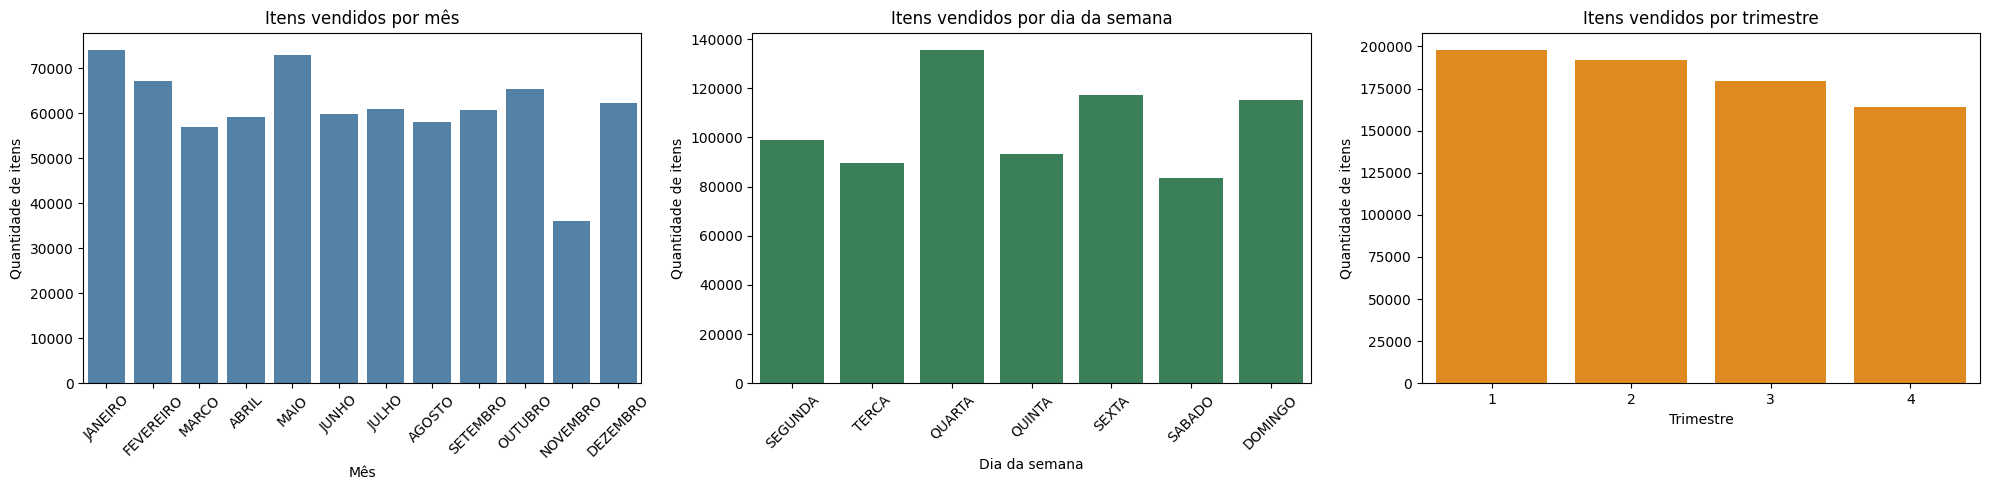

In [24]:
# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=vendas_por_mes, x='NOME_MES', y='qtd_itens', color='steelblue', ax=axes[0])
axes[0].set_title('Itens vendidos por mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Quantidade de itens')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=vendas_por_dia, x='NOME_DIA', y='qtd_itens', color='seagreen', ax=axes[1])
axes[1].set_title('Itens vendidos por dia da semana')
axes[1].set_xlabel('Dia da semana')
axes[1].set_ylabel('Quantidade de itens')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=sazonalidade_trimestre, x='TRIMESTRE', y='qtd_itens', color='darkorange', ax=axes[2])
axes[2].set_title('Itens vendidos por trimestre')
axes[2].set_xlabel('Trimestre')
axes[2].set_ylabel('Quantidade de itens')

plt.tight_layout()
plt.show()

A análise de sazonalidade mostra que janeiro concentra o maior volume de itens vendidos, enquanto novembro apresenta o menor.

Entre os dias da semana, quarta-feira lidera e sábado registra o menor volume.

 No recorte trimestral, o 1º trimestre é o mais forte e o 4º trimestre o mais fraco, indicando maior movimentação no início do ano e queda gradual ao longo do período analisado.

## **6.2 Produtos e Categorias Mais Vendidos**

Aqui observamos quais categorias concentram mais volume de itens e quais produtos aparecem com maior frequência.

In [25]:
# Vendas por Categoria
vendas_por_categoria = (
    df_feat.groupby('PR_CAT')['ITEM']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='qtd_itens'))

/tmp/ipykernel_55603/1905888876.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_feat.groupby('PR_CAT')['ITEM']


In [26]:
# Top 20 Produtos Mais Vendidos
top_produtos = (
    df_feat['PR_NOME']
    .value_counts()
    .head(20)
    .reset_index())
top_produtos.columns = ['PR_NOME', 'qtd_itens']

In [27]:
# Tabela
display(vendas_por_categoria)
display(top_produtos)

,PR_CAT,qtd_itens
0,ALIMENTOS,384197
1,HIGIENE,137702
2,LIMPEZA,128632
3,BEBIDAS,38264
4,PET,28553
5,ACESSORIOS,12871
6,#N/D,3228


,PR_NOME,qtd_itens
0,PRESUNTO COZIDO,12719
1,SARDINHA,6610
2,BANANA,6518
3,ESCOVA DE DENTE,6518
4,GEL,6517
5,PAPINHA INFANTIL,6515
6,MODELADOR,6505
7,CERA,6502
8,CEBOLA,6501
9,LIMPADOR PERFUMADO,6501


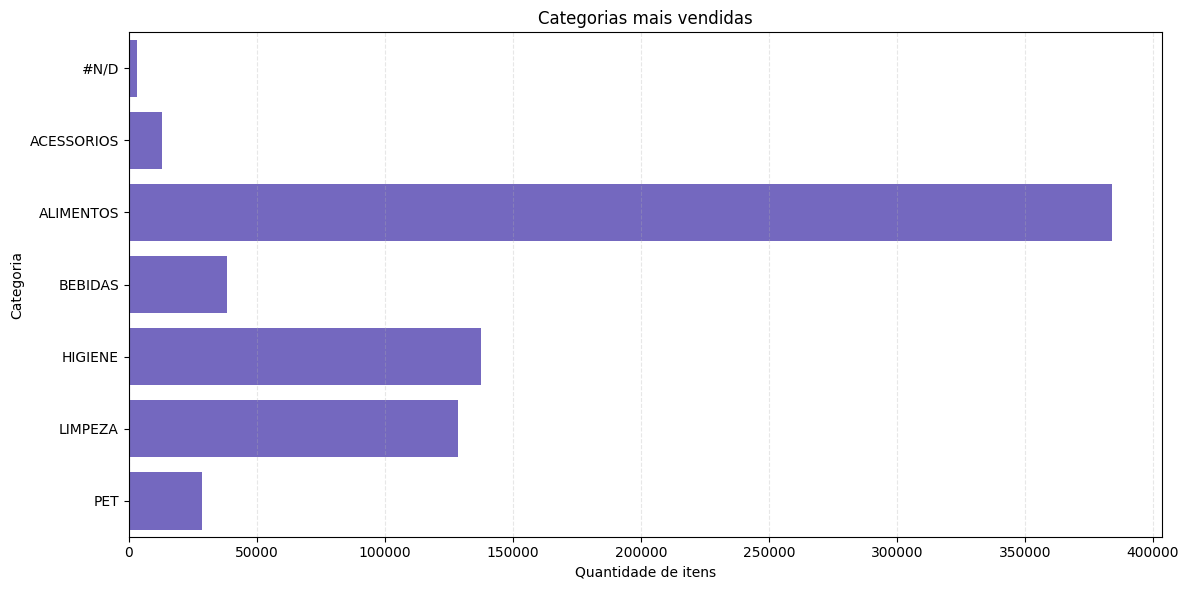

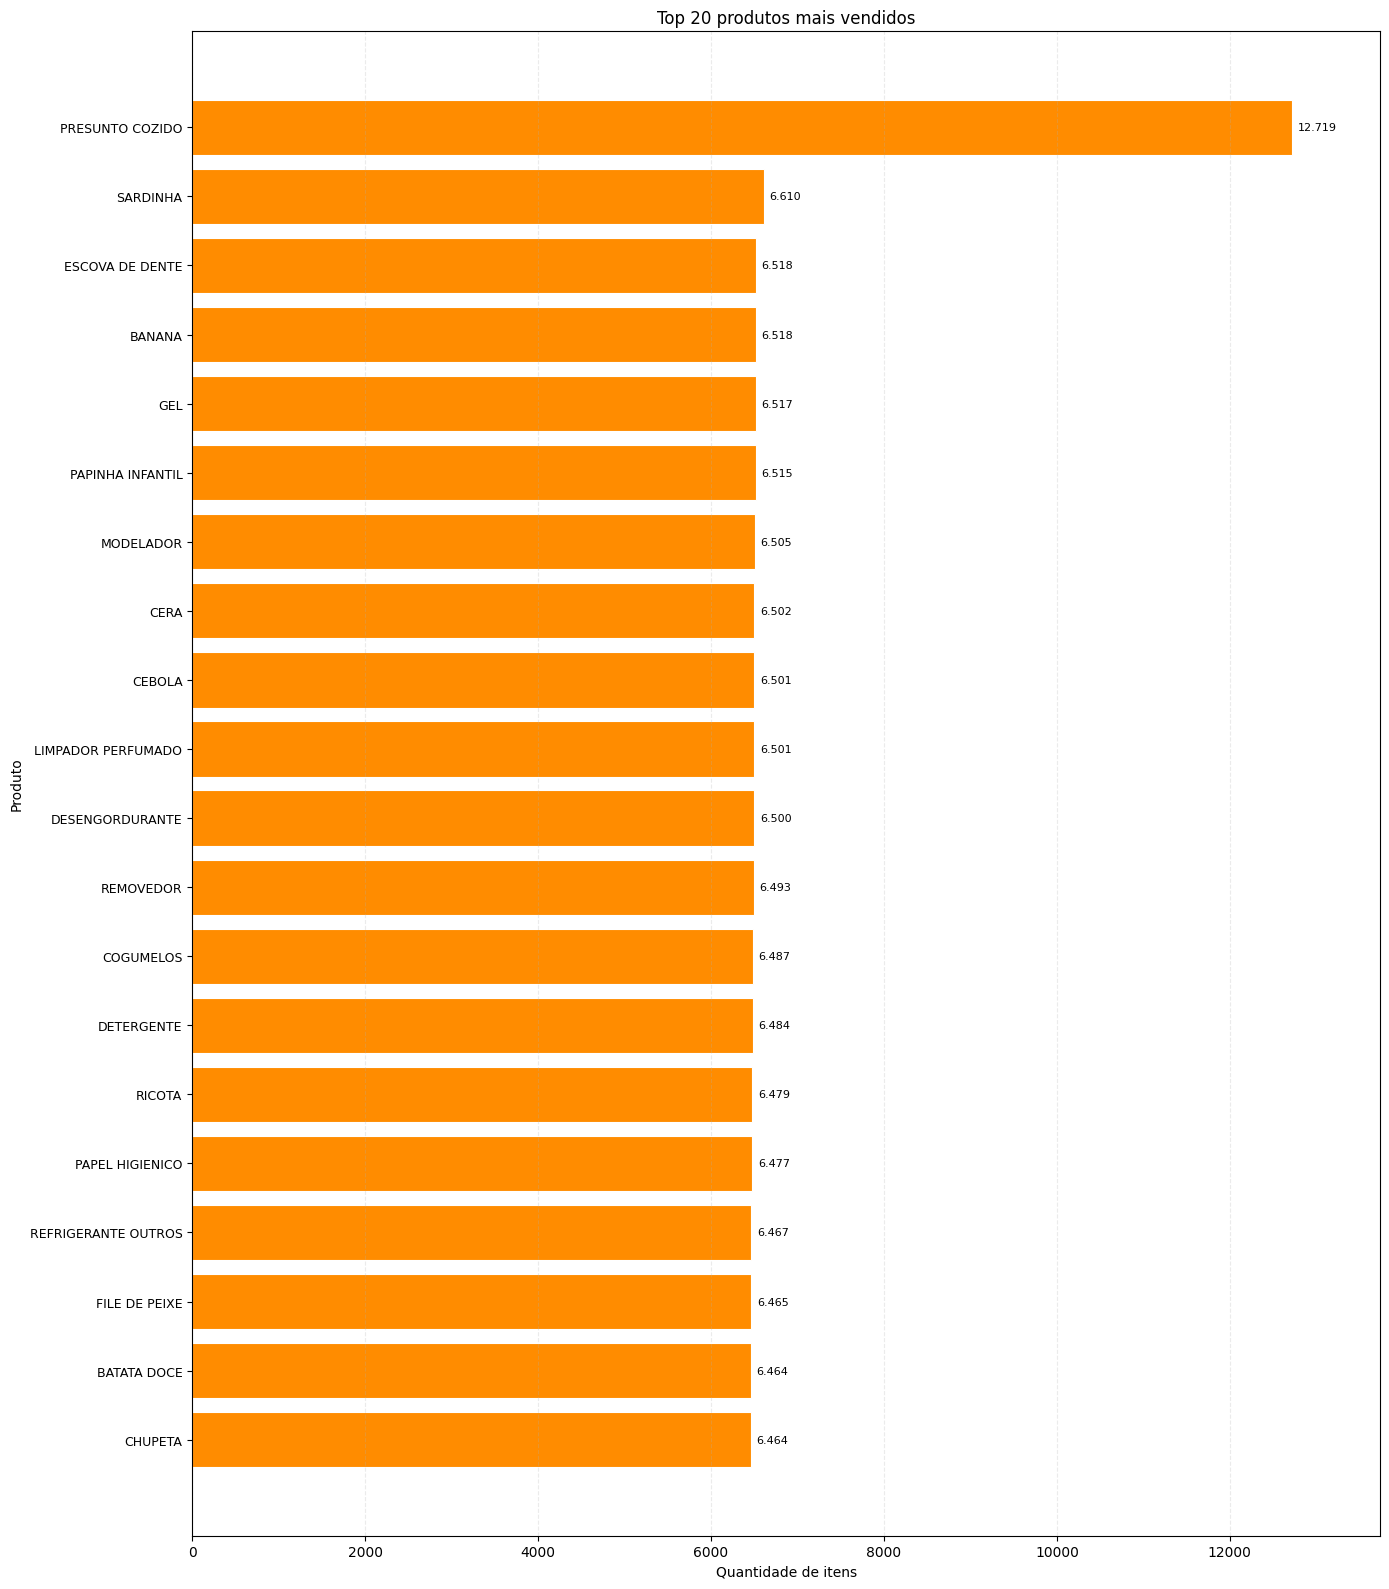

In [28]:
# Gráficos
vendas_por_categoria_plot = vendas_por_categoria.sort_values('qtd_itens', ascending=True)
top_produtos_plot = top_produtos.sort_values('qtd_itens', ascending=True)

# Gráfico 1: categorias mais vendidas
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=vendas_por_categoria_plot,
    x='qtd_itens',
    y='PR_CAT',
    color='slateblue',
    ax=ax
)
ax.set_title('Categorias mais vendidas')
ax.set_xlabel('Quantidade de itens')
ax.set_ylabel('Categoria')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

# Gráfico 2: top 20 produtos mais vendidos
from textwrap import fill

top_produtos_plot = (
    top_produtos
    .sort_values('qtd_itens', ascending=False)
    .head(20)
    .sort_values('qtd_itens', ascending=True)
    .copy()
)

top_produtos_plot['PR_NOME'] = top_produtos_plot['PR_NOME'].apply(lambda x: fill(str(x), width=20))

fig, ax = plt.subplots(figsize=(14, 16))

bars = ax.barh(
    top_produtos_plot['PR_NOME'],
    top_produtos_plot['qtd_itens'],
    color='darkorange',
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Top 20 produtos mais vendidos')
ax.set_xlabel('Quantidade de itens')
ax.set_ylabel('Produto')
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.tick_params(axis='y', labelsize=9)
ax.margins(x=0.08)

ax.bar_label(
    bars,
    labels=[f'{v:,.0f}'.replace(',', '.') for v in top_produtos_plot['qtd_itens']],
    padding=4,
    fontsize=8
)

plt.tight_layout()
plt.show()


- Categorias mais vendidas

A distribuição das vendas mostra forte predominância de ALIMENTOS, seguida por HIGIENE e LIMPEZA. As categorias BEBIDAS e PET aparecem com participação menor, enquanto #N/D representa uma parcela residual da base. Esse resultado indica que o consumo está concentrado principalmente em itens básicos e de compra recorrente.

- Top 20 produtos mais vendidos

No ranking dos produtos, PRESUNTO COZIDO se destaca com folga em relação aos demais. A partir do segundo colocado, os valores ficam muito próximos entre si, o que mostra uma distribuição mais equilibrada entre os produtos mais vendidos.

 No geral, o ranking revela uma cesta de itens diversificada e com alta frequência de compra.

## **6.3 Resumo da compra**

Resumimos cada compra em três indicadores:

- quantidade total de itens;
- quantidade de produtos diferentes;
- quantidade de categorias distintas.

In [29]:
# Resumo da Compra
resumo_compra = (
    df_feat.groupby(['CO_ID', 'CL_ID', 'DATA'])
    .agg(
        qtd_itens=('ITEM', 'sum'),
        qtd_produtos_diferentes=('PR_ID', 'nunique'),
        qtd_categorias=('PR_CAT', 'nunique')).reset_index())
display(resumo_compra.head())
display(resumo_compra[['qtd_itens', 'qtd_produtos_diferentes', 'qtd_categorias']].describe())

,CO_ID,CL_ID,DATA,qtd_itens,qtd_produtos_diferentes,qtd_categorias
0,1000,534,2019-02-01,46,46,4
1,1040,279,2019-02-01,15,15,5
2,1078,290,2019-02-01,63,63,7
3,1082,323,2019-02-01,62,62,5
4,1103,957,2019-02-01,6,6,3


,qtd_itens,qtd_produtos_diferentes,qtd_categorias
count,18471.000000,18471.000000,18471.000000
mean,39.708029,39.708029,5.090899
std,21.336498,21.336498,1.309256
min,1.000000,1.000000,1.000000
25%,22.000000,22.000000,4.000000
50%,41.000000,41.000000,5.000000
75%,58.000000,58.000000,6.000000
max,81.000000,81.000000,7.000000


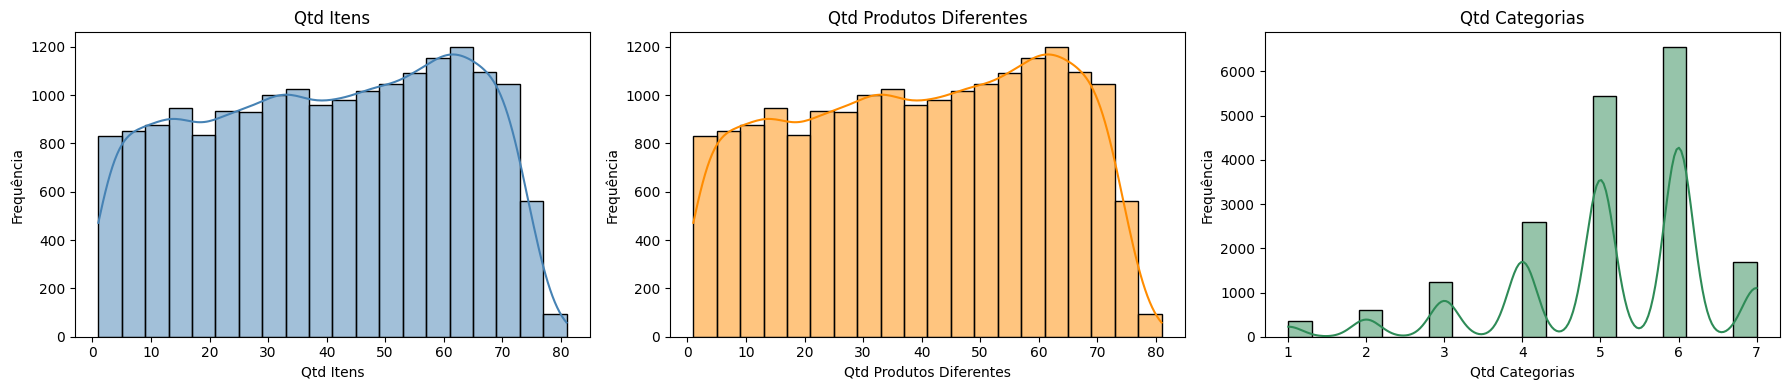

In [30]:
# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colunas = [
    ('qtd_itens', 'steelblue'),
    ('qtd_produtos_diferentes', 'darkorange'),
    ('qtd_categorias', 'seagreen')
]

for ax, (coluna, cor) in zip(axes, colunas):
    sns.histplot(resumo_compra[coluna], bins=20, kde=True, color=cor, ax=ax)
    ax.set_title(coluna.replace('_', ' ').title())
    ax.set_xlabel(coluna.replace('_', ' ').title())
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

Os resultados mostram que uma compra típica reúne cerca de 40 itens, aproximadamente 40 produtos distintos e em torno de 5 categorias, com mediana de 41 itens e 5 categorias.

Os histogramas reforçam esse padrão, indicando maior concentração das compras entre 30 e 70 itens, enquanto o número de categorias se concentra principalmente entre 5 e 6.

Isso sugere cestas de compra com volume relevante e boa variedade de produtos.

## **6.4 Perfil de Consumo dos Clientes**

O objetivo nesta etapa é entender como o consumo se distribui entre classe social, tamanho da família e gênero.

In [31]:
# Consumo por Classe, Família e Gênero
consumo_por_classe = df_feat.groupby('CL_EC')['ITEM'].sum().sort_values(ascending=False).reset_index(name='qtd_itens')

consumo_por_familia = df_feat.groupby('CL_FHL')['ITEM'].sum().sort_values(ascending=False).reset_index(name='qtd_itens')

consumo_por_genero = df_feat.groupby('CL_GENERO')['ITEM'].sum().sort_values(ascending=False).reset_index(name='qtd_itens')

display(consumo_por_classe)
display(consumo_por_familia)
display(consumo_por_genero)

/tmp/ipykernel_55603/945917567.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consumo_por_genero = df_feat.groupby('CL_GENERO')['ITEM'].sum().sort_values(ascending=False).reset_index(name='qtd_itens')


,CL_EC,qtd_itens
0,3,189048
1,4,179206
2,2,172283
3,1,172010
4,5,20900


,CL_FHL,qtd_itens
0,0,384986
1,2,94168
2,3,92407
3,1,90845
4,4,71041


,CL_GENERO,qtd_itens
0,F,382427
1,M,351020


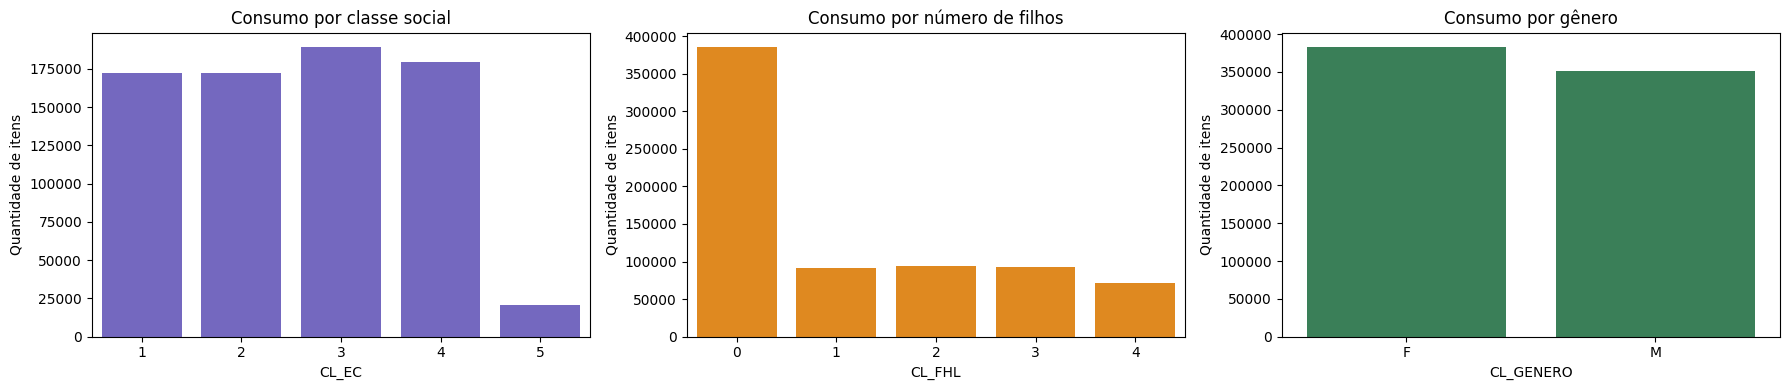

In [32]:
# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=consumo_por_classe, x='CL_EC', y='qtd_itens', color='slateblue', ax=axes[0])
axes[0].set_title('Consumo por classe social')
axes[0].set_xlabel('CL_EC')
axes[0].set_ylabel('Quantidade de itens')

sns.barplot(data=consumo_por_familia, x='CL_FHL', y='qtd_itens', color='darkorange', ax=axes[1])
axes[1].set_title('Consumo por número de filhos')
axes[1].set_xlabel('CL_FHL')
axes[1].set_ylabel('Quantidade de itens')

sns.barplot(data=consumo_por_genero, x='CL_GENERO', y='qtd_itens', color='seagreen', ax=axes[2])
axes[2].set_title('Consumo por gênero')
axes[2].set_xlabel('CL_GENERO')
axes[2].set_ylabel('Quantidade de itens')

plt.tight_layout()
plt.show()

- Consumo por classe social

O consumo se concentra principalmente nas classes 1 a 4, com destaque para a classe 3, que apresenta o maior volume de itens. A classe 5 aparece bem abaixo das demais, indicando menor participação no total de compras.

- Consumo por número de filhos

Os lares sem filhos concentram o maior consumo. Entre as famílias com 1 a 4 filhos, os valores ficam menores e relativamente próximos entre si, mostrando que o tamanho da família influencia o volume de compra.

- Consumo por gênero

O consumo é ligeiramente maior entre o público feminino, mas a diferença em relação ao masculino é pequena. Isso indica um padrão de compra bastante equilibrado entre os gêneros.

## **6.5 Cruzamentos entre Perfil e Categoria**

Aqui comparamos quais categorias aparecem com mais frequência em cada grupo de clientes.

In [33]:
# Categoria por Classe, Família e Gênero
cat_por_classe = pd.crosstab(df_feat['CL_EC'], df_feat['PR_CAT'])

cat_por_familia = pd.crosstab(df_feat['CL_FHL'], df_feat['PR_CAT'])

cat_por_genero = pd.pivot_table(
    df_feat,
    index='CL_GENERO',
    columns='PR_CAT',
    values='ITEM',
    aggfunc='sum',
    fill_value=0)

display(cat_por_classe)
display(cat_por_familia)
display(cat_por_genero)

/tmp/ipykernel_55603/251129521.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cat_por_genero = pd.pivot_table(


PR_CAT,#N/D,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET
CL_EC,,,,,,,
1,766,2993,90143,8969,32287,30088,6764
2,803,3006,90379,9109,32172,30121,6693
3,810,3411,98817,9805,35615,33218,7372
4,776,3115,93872,9254,33770,31509,6910
5,73,346,10986,1127,3858,3696,814


PR_CAT,#N/D,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET
CL_FHL,,,,,,,
0,1683,6755,201670,19991,72302,67625,14960
1,406,1564,47613,4901,17018,15782,3561
2,406,1647,49269,4895,17647,16583,3721
3,400,1689,48284,4812,17487,16148,3587
4,333,1216,37361,3665,13248,12494,2724


PR_CAT,#N/D,ACESSORIOS,ALIMENTOS,BEBIDAS,HIGIENE,LIMPEZA,PET
CL_GENERO,,,,,,,
F,1692,6839,200274,19764,71721,67328,14809
M,1536,6032,183923,18500,65981,61304,13744


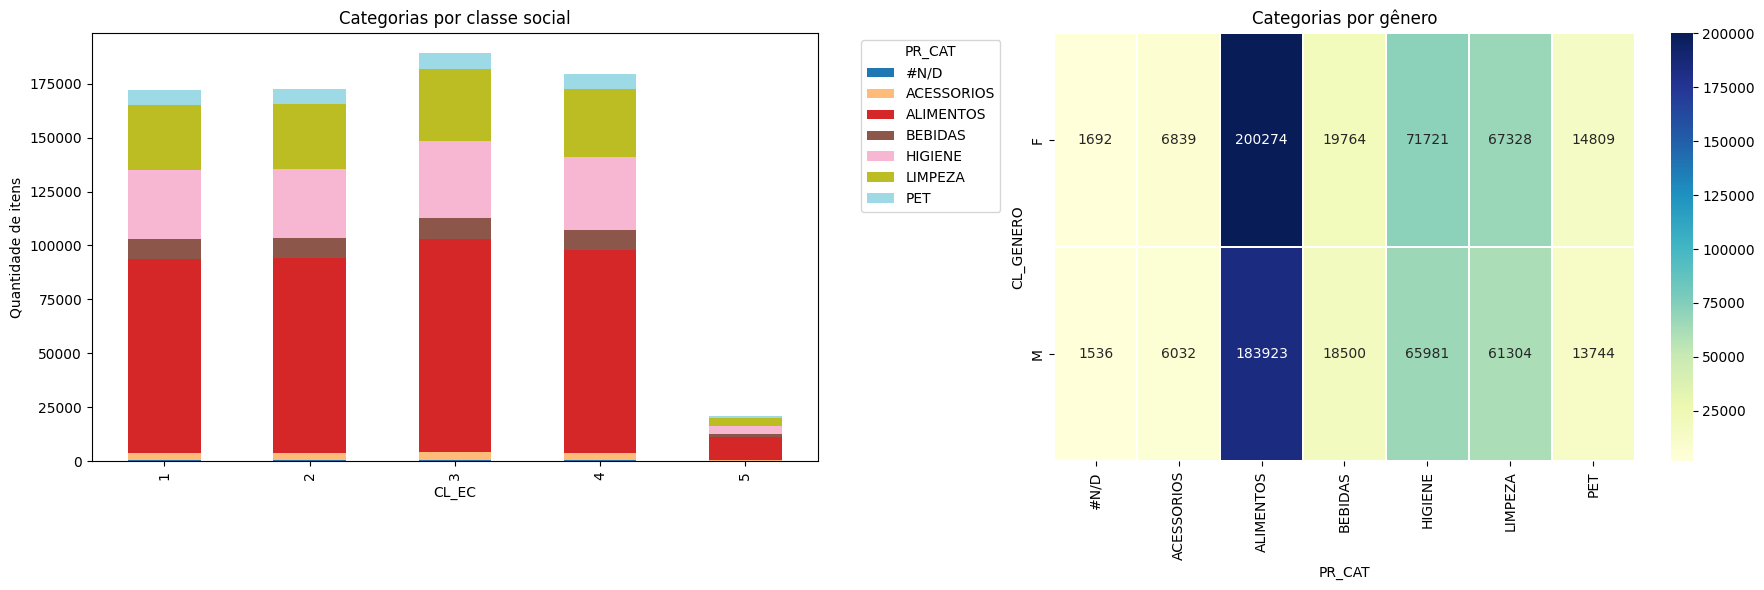

In [34]:
# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cat_por_classe.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Categorias por classe social')
axes[0].set_xlabel('CL_EC')
axes[0].set_ylabel('Quantidade de itens')
axes[0].legend(title='PR_CAT', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.heatmap(cat_por_genero, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.3, linecolor='white', ax=axes[1])
axes[1].set_title('Categorias por gênero')
axes[1].set_xlabel('PR_CAT')
axes[1].set_ylabel('CL_GENERO')

plt.tight_layout()
plt.show()

- Categorias por classe social

A distribuição das compras por classe social mostra predominância de ALIMENTOS em todos os grupos, seguida por HIGIENE e LIMPEZA. As classes 1 a 4 apresentam volumes parecidos, com destaque para a classe 3, que concentra o maior consumo. Já a classe 5 tem participação bem menor no total de itens.

- Categorias por gênero

Entre os gêneros, o padrão de consumo é bastante parecido, com leve vantagem para o público feminino na maioria das categorias. ALIMENTOS é a categoria mais forte em ambos os grupos, enquanto HIGIENE e LIMPEZA também aparecem com destaque. Isso indica que o perfil de compra é semelhante entre homens e mulheres.


## **6.6 Classe Social e Tamanho da Família**

Verificamos nesta etapa a relação entre classe social e tamanho de família, tanto em valores absolutos quanto em percentual.

In [35]:
# Classe Social e Tamanho da Família
heatmap_ec_fhl = pd.crosstab(df_feat['CL_EC'], df_feat['CL_FHL'])
heatmap_ec_fhl_pct = pd.crosstab(df_feat['CL_EC'], df_feat['CL_FHL'], normalize='index') * 100

display(heatmap_ec_fhl)
display(heatmap_ec_fhl_pct.round(1))

CL_FHL,0,1,2,3,4
CL_EC,,,,,
1,95234,15532,14063,20739,26442
2,85391,15733,26685,27129,17345
3,100815,18603,23129,19247,27254
4,103546,28906,23829,22925,0
5,0,12071,6462,2367,0


CL_FHL,0,1,2,3,4
CL_EC,,,,,
1,55.4,9.0,8.2,12.1,15.4
2,49.6,9.1,15.5,15.7,10.1
3,53.3,9.8,12.2,10.2,14.4
4,57.8,16.1,13.3,12.8,0.0
5,0.0,57.8,30.9,11.3,0.0


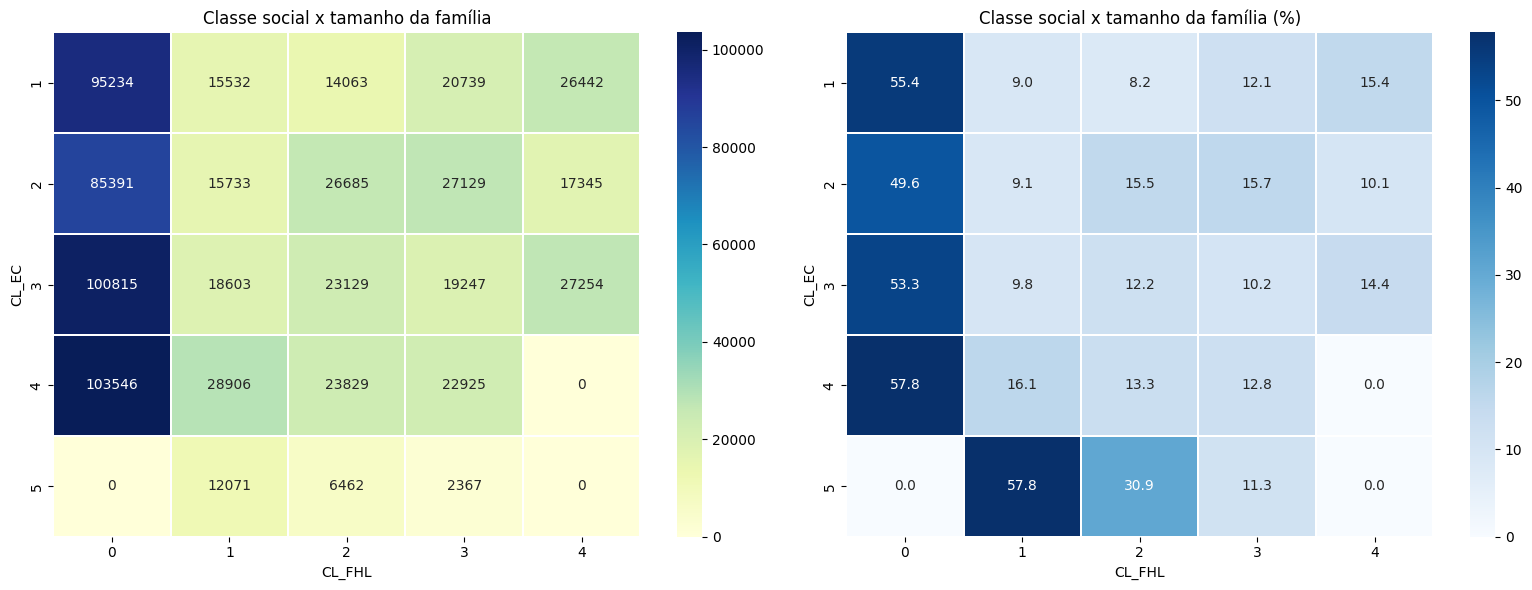

In [36]:
# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(heatmap_ec_fhl, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.3, linecolor='white', ax=axes[0])
axes[0].set_title('Classe social x tamanho da família')
axes[0].set_xlabel('CL_FHL')
axes[0].set_ylabel('CL_EC')

sns.heatmap(heatmap_ec_fhl_pct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.3, linecolor='white', ax=axes[1])
axes[1].set_title('Classe social x tamanho da família (%)')
axes[1].set_xlabel('CL_FHL')
axes[1].set_ylabel('CL_EC')

plt.tight_layout()
plt.show()

 Em valores absolutos, as classes 1 a 4 concentram a maior parte dos registros, com destaque para famílias sem filhos e com até 4 filhos.

 No recorte percentual, cada classe apresenta uma composição própria, mas a presença de famílias menores continua predominando na maior parte dos grupos.

 A classe 5 tem menor volume total e aparece mais concentrada em poucos tamanhos de família.

## **5.7 Evolução temporal das vendas**

Nesta parte, observamos a sazonalidade, mudanças de comportamento e tendências.

In [37]:
# Evolução Anual das Vendas
vendas_por_ano = (
    df_feat.groupby('ANO')['ITEM']
    .sum()
    .reset_index(name='qtd_itens')
)
vendas_por_ano_resumo = vendas_por_ano.sort_values('qtd_itens', ascending=False)
display(vendas_por_ano_resumo)

ano_mais_vendido = vendas_por_ano_resumo.iloc[0]['ANO']
ano_menos_vendido = vendas_por_ano_resumo.iloc[-1]['ANO']
print(f'Ano com mais vendas: {ano_mais_vendido}')
print(f'Ano com menos vendas: {ano_menos_vendido}')

vendas_mensais = (
    df_feat.groupby(['ANO', 'MES'])['ITEM']
    .sum()
    .reset_index(name='qtd_itens')
)
vendas_mensais['DATA_REF'] = pd.to_datetime(
    vendas_mensais['ANO'].astype(str) + '-' + vendas_mensais['MES'].astype(str) + '-01'
)

vendas_trimestre_ano = (
    df_feat.groupby(['ANO', 'TRIMESTRE'])['ITEM']
    .sum()
    .reset_index(name='qtd_itens')
)
vendas_trimestre_ano['PERIODO'] = (
    vendas_trimestre_ano['ANO'].astype(str) + ' T' + vendas_trimestre_ano['TRIMESTRE'].astype(str)
)

,ANO,qtd_itens
2,2021,216813
1,2020,192804
0,2019,176103
3,2022,147727


Ano com mais vendas: 2021
Ano com menos vendas: 2022


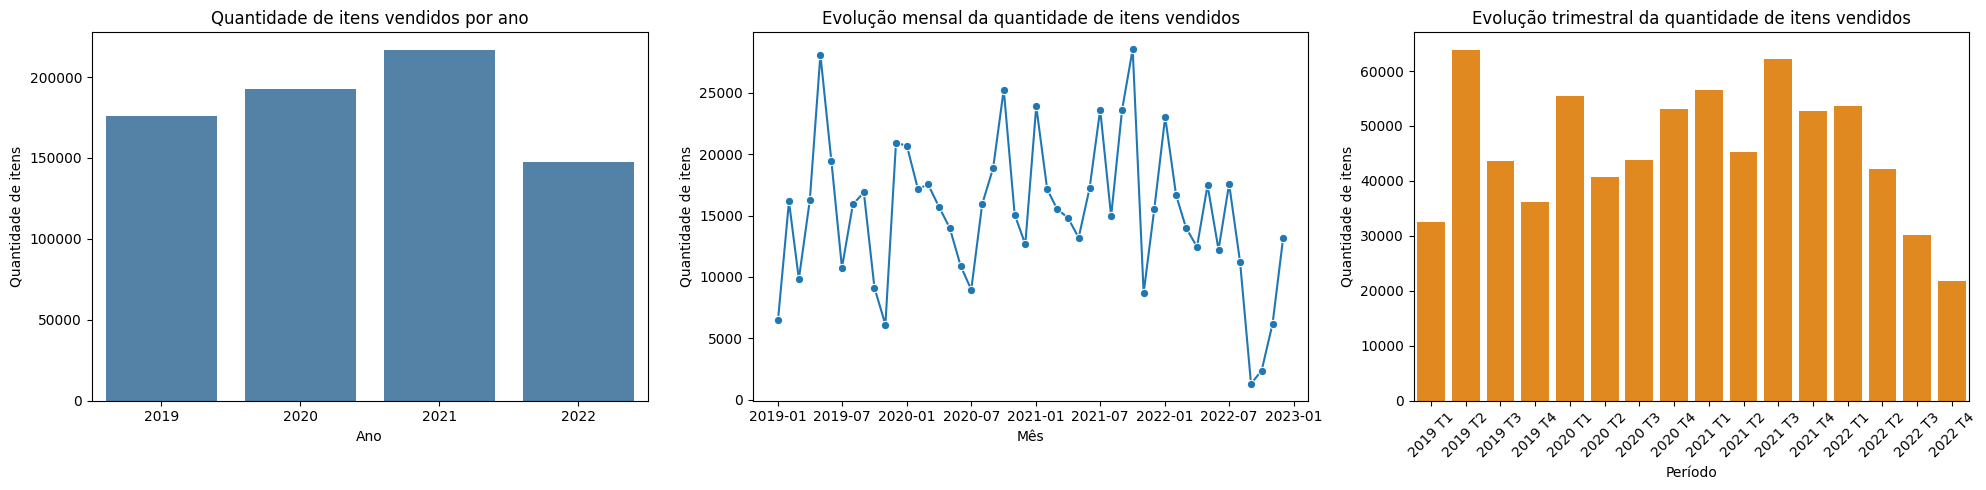

In [38]:
# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

vendas_por_ano_plot = vendas_por_ano.sort_values('ANO')
sns.barplot(data=vendas_por_ano_plot, x='ANO', y='qtd_itens', color='steelblue', ax=axes[0])
axes[0].set_title('Quantidade de itens vendidos por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Quantidade de itens')

vendas_mensais_plot = vendas_mensais.sort_values('DATA_REF')
sns.lineplot(data=vendas_mensais_plot, x='DATA_REF', y='qtd_itens', marker='o', ax=axes[1])
axes[1].set_title('Evolução mensal da quantidade de itens vendidos')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Quantidade de itens')

vendas_trimestre_ano_plot = vendas_trimestre_ano.sort_values(['ANO', 'TRIMESTRE'])
sns.barplot(data=vendas_trimestre_ano_plot, x='PERIODO', y='qtd_itens', color='darkorange', ax=axes[2])
axes[2].set_title('Evolução trimestral da quantidade de itens vendidos')
axes[2].set_xlabel('Período')
axes[2].set_ylabel('Quantidade de itens')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

A evolução temporal mostra crescimento das vendas entre 2019 e 2021, com 2021 sendo o ano de maior volume.

Em 2022, há uma queda em relação ao ano anterior, o que também aparece na série mensal, com oscilações ao longo do período e queda mais forte no fim da base.

No recorte trimestral, os melhores desempenhos se concentram em 2019 T2 e 2021 T2, enquanto os menores volumes aparecem em 2022 T4, indicando enfraquecimento no final do período analisado.

# **7. Conclusões**



Ao longo desta análise, foi possível transformar a base em um conjunto de dados mais confiável, consistente e pronto para exploração. Após a limpeza, a padronização dos tipos, a verificação de qualidade e a identificação de inconsistências pontuais, a estrutura dos dados se mostrou adequada para análises descritivas, cruzamentos e leitura gerencial dos resultados.

Os achados revelam um padrão de consumo fortemente concentrado em ALIMENTOS, seguido por HIGIENE e LIMPEZA, o que evidencia a predominância de itens de compra recorrente e de necessidade básica. Entre os produtos, PRESUNTO COZIDO se destacou com grande vantagem, enquanto os demais itens do ranking apresentaram volumes muito próximos entre si, sugerindo uma cesta de consumo diversificada e relativamente equilibrada.

Na análise por transação, observou-se que as compras costumam reunir cerca de 40 itens, aproximadamente 40 produtos distintos e em torno de 5 categorias, o que reforça a ideia de cestas com bom volume e variedade. Já no perfil dos consumidores, o maior consumo está concentrado nas classes sociais 1 a 4, com destaque para a classe 3. Famílias sem filhos também apresentam maior participação no volume total de itens, enquanto a diferença entre os gêneros é pequena, com leve predominância do público feminino.

Os cruzamentos entre classe social e tamanho da família confirmam que a maior parte das compras está associada a lares menores e grupos intermediários da base. No recorte temporal, a evolução das vendas mostra crescimento entre 2019 e 2021, com 2021 como o ano de melhor desempenho, seguido de queda em 2022. Mensalmente, janeiro se destaca como o período de maior movimento, enquanto novembro registra o menor volume. No comportamento semanal, quarta-feira lidera as vendas e sábado apresenta menor intensidade. Por trimestre, o primeiro trimestre é o mais forte e o quarto trimestre o mais fraco, apontando uma desaceleração gradual ao final do período analisado.

Em síntese, os resultados indicam uma operação centrada em itens essenciais, com padrão de compra frequente, volume relevante por transação e concentração clara em determinados perfis de consumo.

Além de revelar tendências importantes sobre produtos, categorias, tempo e perfil dos clientes, a análise também reforça a importância da qualidade dos dados como etapa fundamental para gerar conclusões confiáveis e úteis.